In [3]:
import os
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
import optuna

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
scaler = joblib.load("../data/processed/X_scaler.pkl")
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")
X_trainVal = np.load("../data/processed/X_trainVal.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")
y_trainVal = np.load("../data/processed/y_trainVal.npy")
y_scaler = joblib.load("../data/processed/y_scaler.pkl")

with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)


In [6]:
class FinalParkinsonNN(nn.Module):
    def __init__(self, params, input_dim=18):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, params["units_l1"]), nn.ReLU(),
            nn.Linear(params["units_l1"], params["units_l2"]), nn.ReLU(),
            nn.Dropout(params["dropout"]),
            nn.Linear(params["units_l2"], params["units_l3"]), nn.ReLU(),
            nn.Linear(params["units_l3"], params["units_l4"]), nn.ReLU(),
            nn.Linear(params["units_l4"], 2)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
with open("../models/best_nn_params.json", "r") as f:
    params = json.load(f)

In [8]:
nn_model = FinalParkinsonNN(params).to(DEVICE)
nn_model.load_state_dict(torch.load("../models/best_nn_model.pt"))
nn_model.eval()

rf_expert = joblib.load("../models/rf_expert.pkl")

In [9]:
# NN
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    nn_train_preds_scaled = nn_model(X_train_tensor).cpu().numpy()
    nn_val_preds_scaled = nn_model(X_val_tensor).cpu().numpy()
    nn_test_preds_scaled = nn_model(X_test_tensor).cpu().numpy()
    
# RF
rf_train_preds_scaled = rf_expert.predict(X_train)
rf_val_preds_scaled = rf_expert.predict(X_val)
rf_test_preds_scaled = rf_expert.predict(X_test)


In [10]:
gate_train = np.concatenate([
    X_train,
    rf_train_preds_scaled,
    nn_train_preds_scaled
], axis=1)

gate_val = np.concatenate([
    X_val,
    rf_val_preds_scaled,
    nn_val_preds_scaled
], axis=1)

gate_test = np.concatenate([
    X_test,
    rf_test_preds_scaled,
    nn_test_preds_scaled
], axis=1)

print("Gate input shape:", gate_train.shape)

Gate input shape: (3760, 22)


In [11]:
class GateDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        rf_preds,
        nn_preds
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

        self.rf_preds = torch.tensor(
            rf_preds,
            dtype=torch.float32
        )

        self.nn_preds = torch.tensor(
            nn_preds,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx],
            self.rf_preds[idx],
            self.nn_preds[idx]
        )


In [12]:
class AdaptiveGate(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        dropout_rate,
        temperature
    ):

        super().__init__()

        self.temperature = temperature

        self.net = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, 2)

        )

    def forward(self, x):

        logits = self.net(x)

        weights = torch.softmax(
            logits / self.temperature,
            dim=1
        )

        return weights

In [13]:
def train_gate(
    trial,
    target_idx
):

    # --------------------------------------------------------
    # Hyperparameters
    # --------------------------------------------------------

    hidden_dim = trial.suggest_categorical(
        "hidden_dim",
        [8, 16, 32]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.0,
        0.3
    )

    temperature = trial.suggest_categorical(
        "temperature",
        [0.5, 1.0, 2.0]
    )

    entropy_lambda = trial.suggest_categorical(
        "entropy_lambda",
        [0.0, 0.001, 0.01, 0.05]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = AdaptiveGate(
        input_dim=gate_train.shape[1],
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
        temperature=temperature
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    mse_loss = nn.MSELoss()

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_dataset = GateDataset(
        gate_train,
        y_train,
        rf_train_preds_scaled,
        nn_train_preds_scaled
    )

    val_dataset = GateDataset(
        gate_val,
        y_val,
        rf_val_preds_scaled,
        nn_val_preds_scaled
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    best_val_loss = np.inf
    patience = 20
    counter = 0

    best_model = None

    # ========================================================
    # TRAIN LOOP
    # ========================================================

    for epoch in range(200):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        train_loss = 0

        for (
            X_batch,
            y_batch,
            rf_batch,
            nn_batch
        ) in train_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            rf_batch = rf_batch.to(DEVICE)
            nn_batch = nn_batch.to(DEVICE)

            optimizer.zero_grad()

            weights = model(X_batch)

            rf_weight = weights[:, 0]
            nn_weight = weights[:, 1]

            final_pred = (
                rf_weight * rf_batch[:, target_idx]
                +
                nn_weight * nn_batch[:, target_idx]
            )

            target = y_batch[:, target_idx]

            pred_loss = mse_loss(
                final_pred,
                target
            )

            # ------------------------------------------------
            # Entropy Regularization
            # ------------------------------------------------

            entropy = -torch.mean(
                torch.sum(
                    weights * torch.log(weights + 1e-8),
                    dim=1
                )
            )

            loss = pred_loss - (
                entropy_lambda * entropy
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        val_loss = 0

        with torch.no_grad():

            for (
                X_batch,
                y_batch,
                rf_batch,
                nn_batch
            ) in val_loader:

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                rf_batch = rf_batch.to(DEVICE)
                nn_batch = nn_batch.to(DEVICE)

                weights = model(X_batch)

                rf_weight = weights[:, 0]
                nn_weight = weights[:, 1]

                final_pred = (
                    rf_weight * rf_batch[:, target_idx]
                    +
                    nn_weight * nn_batch[:, target_idx]
                )

                target = y_batch[:, target_idx]

                pred_loss = mse_loss(
                    final_pred,
                    target
                )

                entropy = -torch.mean(
                    torch.sum(
                        weights * torch.log(weights + 1e-8),
                        dim=1
                    )
                )

                loss = pred_loss - (
                    entropy_lambda * entropy
                )

                val_loss += loss.item()

        val_loss /= len(val_loader)

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

            if counter >= patience:
                break

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    model.load_state_dict(best_model)

    trial.set_user_attr(
        "best_model",
        model.state_dict()
    )

    return best_val_loss

In [17]:
print("\nTuning Motor Gate...")

motor_study = optuna.create_study(
    direction="minimize"
)

motor_study.optimize(
    lambda trial: train_gate(
        trial,
        target_idx=0
    ),
    n_trials=25
)

print("\nBest Motor Params:")
print(motor_study.best_params)

[I 2026-05-11 09:12:17,226] A new study created in memory with name: no-name-1288048d-a454-4694-8c01-1b79097a8ef2



Tuning Motor Gate...


[I 2026-05-11 09:12:48,892] Trial 0 finished with value: 0.01123530964832753 and parameters: {'hidden_dim': 32, 'learning_rate': 0.0008982890091861005, 'dropout_rate': 0.23262255373884505, 'temperature': 1.0, 'entropy_lambda': 0.0, 'batch_size': 128}. Best is trial 0 with value: 0.01123530964832753.
[I 2026-05-11 09:13:14,752] Trial 1 finished with value: 0.009584660758264363 and parameters: {'hidden_dim': 32, 'learning_rate': 0.0003350176842747816, 'dropout_rate': 0.07578221578096651, 'temperature': 0.5, 'entropy_lambda': 0.01, 'batch_size': 128}. Best is trial 1 with value: 0.009584660758264363.
[I 2026-05-11 09:14:32,718] Trial 2 finished with value: 0.011432630242779851 and parameters: {'hidden_dim': 16, 'learning_rate': 0.0001683391833576903, 'dropout_rate': 0.2392746318277818, 'temperature': 2.0, 'entropy_lambda': 0.0, 'batch_size': 32}. Best is trial 1 with value: 0.009584660758264363.
[I 2026-05-11 09:14:59,038] Trial 3 finished with value: 0.011247410904616117 and parameters: 


Best Motor Params:
{'hidden_dim': 8, 'learning_rate': 0.0019122748228268711, 'dropout_rate': 0.04470145327296845, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 64}


In [18]:
print("\nTuning Total Gate...")

total_study = optuna.create_study(
    direction="minimize"
)

total_study.optimize(
    lambda trial: train_gate(
        trial,
        target_idx=1
    ),
    n_trials=25
)

print("\nBest Total Params:")
print(total_study.best_params)

[I 2026-05-11 09:30:47,414] A new study created in memory with name: no-name-a8e72206-f8ea-4213-bede-1a6df1e3f388



Tuning Total Gate...


[I 2026-05-11 09:31:43,312] Trial 0 finished with value: 0.006947501818649471 and parameters: {'hidden_dim': 16, 'learning_rate': 0.005105798136444006, 'dropout_rate': 0.23848220981170662, 'temperature': 2.0, 'entropy_lambda': 0.01, 'batch_size': 32}. Best is trial 0 with value: 0.006947501818649471.
[I 2026-05-11 09:32:11,309] Trial 1 finished with value: 0.0066633959650062025 and parameters: {'hidden_dim': 16, 'learning_rate': 0.0018988601243312567, 'dropout_rate': 0.05983729885865221, 'temperature': 0.5, 'entropy_lambda': 0.01, 'batch_size': 128}. Best is trial 1 with value: 0.0066633959650062025.
[I 2026-05-11 09:32:26,926] Trial 2 finished with value: -0.01542852132115513 and parameters: {'hidden_dim': 16, 'learning_rate': 0.009650992494171564, 'dropout_rate': 0.21059058296795635, 'temperature': 2.0, 'entropy_lambda': 0.05, 'batch_size': 128}. Best is trial 2 with value: -0.01542852132115513.
[I 2026-05-11 09:32:47,006] Trial 3 finished with value: -0.015144781519969305 and parame


Best Total Params:
{'hidden_dim': 32, 'learning_rate': 0.0018123769960513428, 'dropout_rate': 0.07826676875662475, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 128}


In [15]:
def build_best_gate(best_params):

    model = AdaptiveGate(

        input_dim=gate_train.shape[1],

        hidden_dim=best_params["hidden_dim"],

        dropout_rate=best_params["dropout_rate"],

        temperature=best_params["temperature"]

    ).to(DEVICE)

    return model

In [13]:
best_motor_gate_params = {'hidden_dim': 8, 'learning_rate': 0.0019122748228268711, 'dropout_rate': 0.04470145327296845, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 64}

best_total_gate_params = {'hidden_dim': 32, 'learning_rate': 0.0018123769960513428, 'dropout_rate': 0.07826676875662475, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 128}

with open("../models/best_motor_gate_params.json", "w") as f:
    json.dump(best_motor_gate_params, f, indent=4)

with open("../models/best_total_gate_params.json", "w") as f:
    json.dump(best_total_gate_params, f, indent=4)

print("Best gate parameters exported.")
print(f"Motor params: {best_motor_gate_params}")
print(f"Total params: {best_total_gate_params}")

Best gate parameters exported.
Motor params: {'hidden_dim': 8, 'learning_rate': 0.0019122748228268711, 'dropout_rate': 0.04470145327296845, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 64}
Total params: {'hidden_dim': 32, 'learning_rate': 0.0018123769960513428, 'dropout_rate': 0.07826676875662475, 'temperature': 1.0, 'entropy_lambda': 0.05, 'batch_size': 128}


In [ ]:
# Save best parameters for both gates
with open("../models/best_motor_gate_params.json", "w") as f:
    json.dump(motor_study.best_params, f, indent=4)

with open("../models/best_total_gate_params.json", "w") as f:
    json.dump(total_study.best_params, f, indent=4)

print("Best gate parameters exported.")
print(f"Motor params: {motor_study.best_params}")
print(f"Total params: {total_study.best_params}")

In [16]:
# Load best parameters from JSON
with open("../models/best_motor_gate_params.json", "r") as f:
    best_motor_gate_params = json.load(f)

with open("../models/best_total_gate_params.json", "r") as f:
    best_total_gate_params = json.load(f)

# Build and train motor gate
motor_gate = build_best_gate(best_motor_gate_params)
motor_optimizer = optim.Adam(
    motor_gate.parameters(),
    lr=best_motor_gate_params["learning_rate"]
)
mse_loss = nn.MSELoss()

# Motor gate training
motor_train_dataset = GateDataset(
    gate_train,
    y_train,
    rf_train_preds_scaled,
    nn_train_preds_scaled
)

motor_val_dataset = GateDataset(
    gate_val,
    y_val,
    rf_val_preds_scaled,
    nn_val_preds_scaled
)

motor_train_loader = DataLoader(
    motor_train_dataset,
    batch_size=best_motor_gate_params["batch_size"],
    shuffle=True
)

motor_val_loader = DataLoader(
    motor_val_dataset,
    batch_size=best_motor_gate_params["batch_size"],
    shuffle=False
)

best_motor_val_loss = np.inf
motor_patience = 20
motor_counter = 0
best_motor_model = None

for epoch in range(200):
    motor_gate.train()
    motor_train_loss = 0
    
    for X_batch, y_batch, rf_batch, nn_batch in motor_train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        rf_batch = rf_batch.to(DEVICE)
        nn_batch = nn_batch.to(DEVICE)
        
        motor_optimizer.zero_grad()
        weights = motor_gate(X_batch)
        
        final_pred = (
            weights[:, 0] * rf_batch[:, 0] +
            weights[:, 1] * nn_batch[:, 0]
        )
        
        pred_loss = mse_loss(final_pred, y_batch[:, 0])
        entropy = -torch.mean(torch.sum(weights * torch.log(weights + 1e-8), dim=1))
        loss = pred_loss - (best_motor_gate_params["entropy_lambda"] * entropy)
        
        loss.backward()
        motor_optimizer.step()
        motor_train_loss += loss.item()
    
    # Validation
    motor_gate.eval()
    motor_val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch, rf_batch, nn_batch in motor_val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            rf_batch = rf_batch.to(DEVICE)
            nn_batch = nn_batch.to(DEVICE)
            
            weights = motor_gate(X_batch)
            final_pred = (
                weights[:, 0] * rf_batch[:, 0] +
                weights[:, 1] * nn_batch[:, 0]
            )
            
            pred_loss = mse_loss(final_pred, y_batch[:, 0])
            entropy = -torch.mean(torch.sum(weights * torch.log(weights + 1e-8), dim=1))
            loss = pred_loss - (best_motor_gate_params["entropy_lambda"] * entropy)
            motor_val_loss += loss.item()
    
    motor_val_loss /= len(motor_val_loader)
    
    if motor_val_loss < best_motor_val_loss:
        best_motor_val_loss = motor_val_loss
        best_motor_model = copy.deepcopy(motor_gate.state_dict())
        motor_counter = 0
    else:
        motor_counter += 1
        if motor_counter >= motor_patience:
            break

motor_gate.load_state_dict(best_motor_model)
motor_gate.eval()

# Build and train total gate
total_gate = build_best_gate(best_total_gate_params)
total_optimizer = optim.Adam(
    total_gate.parameters(),
    lr=best_total_gate_params["learning_rate"]
)

total_train_dataset = GateDataset(
    gate_train,
    y_train,
    rf_train_preds_scaled,
    nn_train_preds_scaled
)

total_val_dataset = GateDataset(
    gate_val,
    y_val,
    rf_val_preds_scaled,
    nn_val_preds_scaled
)

total_train_loader = DataLoader(
    total_train_dataset,
    batch_size=best_total_gate_params["batch_size"],
    shuffle=True
)

total_val_loader = DataLoader(
    total_val_dataset,
    batch_size=best_total_gate_params["batch_size"],
    shuffle=False
)

best_total_val_loss = np.inf
total_patience = 20
total_counter = 0
best_total_model = None

for epoch in range(200):
    total_gate.train()
    total_train_loss = 0
    
    for X_batch, y_batch, rf_batch, nn_batch in total_train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        rf_batch = rf_batch.to(DEVICE)
        nn_batch = nn_batch.to(DEVICE)
        
        total_optimizer.zero_grad()
        weights = total_gate(X_batch)
        
        final_pred = (
            weights[:, 0] * rf_batch[:, 1] +
            weights[:, 1] * nn_batch[:, 1]
        )
        
        pred_loss = mse_loss(final_pred, y_batch[:, 1])
        entropy = -torch.mean(torch.sum(weights * torch.log(weights + 1e-8), dim=1))
        loss = pred_loss - (best_total_gate_params["entropy_lambda"] * entropy)
        
        loss.backward()
        total_optimizer.step()
        total_train_loss += loss.item()
    
    # Validation
    total_gate.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch, rf_batch, nn_batch in total_val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            rf_batch = rf_batch.to(DEVICE)
            nn_batch = nn_batch.to(DEVICE)
            
            weights = total_gate(X_batch)
            final_pred = (
                weights[:, 0] * rf_batch[:, 1] +
                weights[:, 1] * nn_batch[:, 1]
            )
            
            pred_loss = mse_loss(final_pred, y_batch[:, 1])
            entropy = -torch.mean(torch.sum(weights * torch.log(weights + 1e-8), dim=1))
            loss = pred_loss - (best_total_gate_params["entropy_lambda"] * entropy)
            total_val_loss += loss.item()
    
    total_val_loss /= len(total_val_loader)
    
    if total_val_loss < best_total_val_loss:
        best_total_val_loss = total_val_loss
        best_total_model = copy.deepcopy(total_gate.state_dict())
        total_counter = 0
    else:
        total_counter += 1
        if total_counter >= total_patience:
            break

total_gate.load_state_dict(best_total_model)
total_gate.eval()

print("\nBest gates trained and loaded.")


Best gates trained and loaded.


In [17]:
gate_test_tensor = torch.tensor(
    gate_test,
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():

    motor_weights = motor_gate(
        gate_test_tensor
    ).cpu().numpy()

    total_weights = total_gate(
        gate_test_tensor
    ).cpu().numpy()

# ------------------------------------------------------------
# Motor Predictions
# ------------------------------------------------------------

motor_preds = (
    motor_weights[:, 0] * rf_test_preds_scaled[:, 0]
    +
    motor_weights[:, 1] * nn_test_preds_scaled[:, 0]
)

# ------------------------------------------------------------
# Total Predictions
# ------------------------------------------------------------

total_preds = (
    total_weights[:, 0] * rf_test_preds_scaled[:, 1]
    +
    total_weights[:, 1] * nn_test_preds_scaled[:, 1]
)

test_preds = np.stack([
    motor_preds,
    total_preds
], axis=1)

test_preds_rescaled = y_scaler.inverse_transform(test_preds)

In [18]:
def evaluate_regression(
    y_true,
    y_pred,
    label
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    pearson_corr = pearsonr(
        y_true,
        y_pred
    )[0]

    spearman_corr = spearmanr(
        y_true,
        y_pred
    )[0]

    print(f"\n===== {label} =====")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"R2        : {r2:.4f}")
    print(f"Pearson r : {pearson_corr:.4f}")
    print(f"Spearman  : {spearman_corr:.4f}")

# ------------------------------------------------------------
# Motor
# ------------------------------------------------------------

evaluate_regression(
    y_test[:, 0],
    test_preds_rescaled[:, 0],
    "Motor UPDRS"
)

# ------------------------------------------------------------
# Total
# ------------------------------------------------------------

evaluate_regression(
    y_test[:, 1],
    test_preds_rescaled[:, 1],
    "Total UPDRS"
)


===== Motor UPDRS =====
RMSE      : 2.3498
MAE       : 1.7178
R2        : 0.9135
Pearson r : 0.9559
Spearman  : 0.9545

===== Total UPDRS =====
RMSE      : 2.8870
MAE       : 2.1126
R2        : 0.9248
Pearson r : 0.9617
Spearman  : 0.9586


In [23]:
rf_test_preds = y_scaler.inverse_transform(rf_test_preds_scaled)
nn_test_preds = y_scaler.inverse_transform(nn_test_preds_scaled)

evaluate_regression(
    y_test[:, 0],
    rf_test_preds[:, 0],
    "RF Motor"
)

evaluate_regression(
    y_test[:, 0],
    nn_test_preds[:, 0],
    "NN Motor"
)

evaluate_regression(
    y_test[:, 1],
    rf_test_preds[:, 1],
    "RF Total"
)

evaluate_regression(
    y_test[:, 1],
    nn_test_preds[:, 1],
    "NN Total"
)



===== RF Motor =====
RMSE      : 2.3551
MAE       : 1.7013
R2        : 0.9131
Pearson r : 0.9556
Spearman  : 0.9547

===== NN Motor =====
RMSE      : 2.6074
MAE       : 1.9655
R2        : 0.8935
Pearson r : 0.9468
Spearman  : 0.9446

===== RF Total =====
RMSE      : 2.9075
MAE       : 2.1165
R2        : 0.9237
Pearson r : 0.9611
Spearman  : 0.9579

===== NN Total =====
RMSE      : 3.2630
MAE       : 2.4132
R2        : 0.9039
Pearson r : 0.9531
Spearman  : 0.9501


In [24]:
print("\n===== ROUTING ANALYSIS =====")

print("\nMotor Gate:")
print(
    f"Average RF Weight : "
    f"{motor_weights[:,0].mean():.4f}"
)

print(
    f"Average NN Weight : "
    f"{motor_weights[:,1].mean():.4f}"
)

print("\nTotal Gate:")
print(
    f"Average RF Weight : "
    f"{total_weights[:,0].mean():.4f}"
)

print(
    f"Average NN Weight : "
    f"{total_weights[:,1].mean():.4f}"
)


===== ROUTING ANALYSIS =====

Motor Gate:
Average RF Weight : 0.6273
Average NN Weight : 0.3727

Total Gate:
Average RF Weight : 0.6188
Average NN Weight : 0.3812


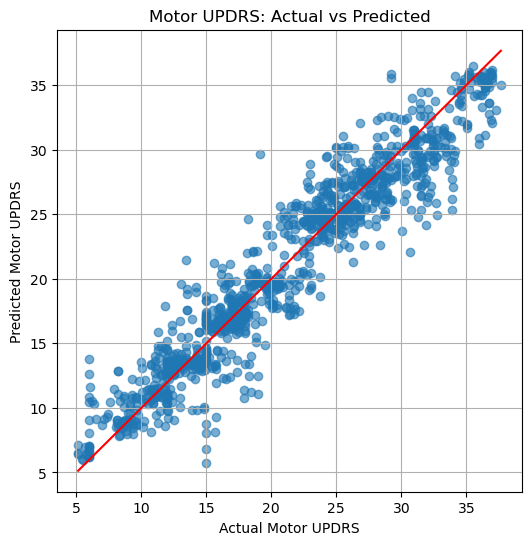

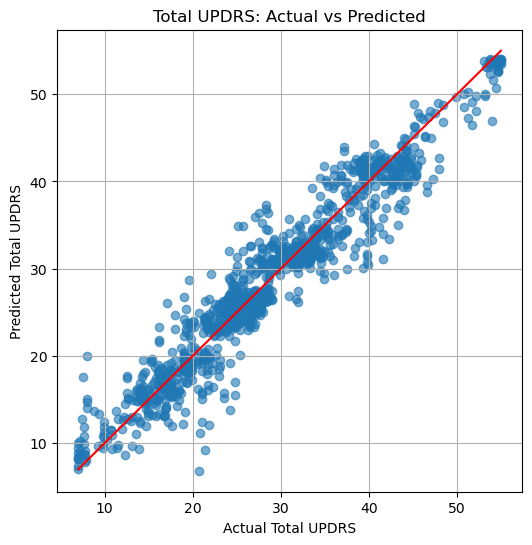

In [25]:
import matplotlib.pyplot as plt

# =====================================================
# Motor UPDRS
# =====================================================

plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    test_preds_rescaled[:,0],
    alpha=0.6
)

plt.plot(
    [
        y_test[:,0].min(),
        y_test[:,0].max()
    ],
    [
        y_test[:,0].min(),
        y_test[:,0].max()
    ],
    linestyle='-',
    color='red'
)

plt.xlabel("Actual Motor UPDRS")
plt.ylabel("Predicted Motor UPDRS")
plt.title("Motor UPDRS: Actual vs Predicted")

plt.grid(True)

plt.savefig("../results/motor_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# Total UPDRS
# =====================================================

plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],
    test_preds_rescaled[:,1],
    alpha=0.6
)

plt.plot(
    [
        y_test[:,1].min(),
        y_test[:,1].max()
    ],
    [
        y_test[:,1].min(),
        y_test[:,1].max()
    ],
    linestyle='-',
    color='red'
)

plt.xlabel("Actual Total UPDRS")
plt.ylabel("Predicted Total UPDRS")
plt.title("Total UPDRS: Actual vs Predicted")

plt.grid(True)

plt.savefig("../results/total_actual_vs_predicted.png", dpi=300, bbox_inches='tight')

plt.show()

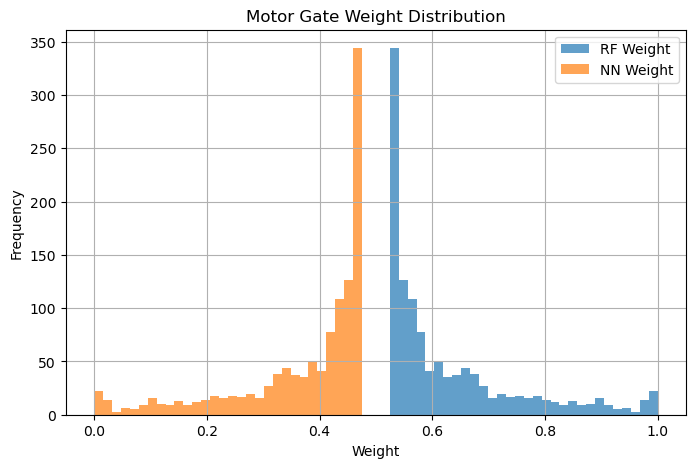

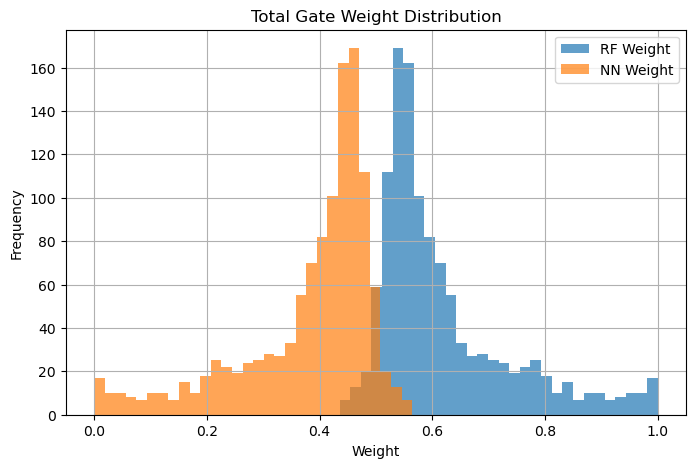

In [30]:
# =====================================================
# Motor Gate Distribution
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    motor_weights[:,0],
    bins=30,
    alpha=0.7,
    label="RF Weight"
)

plt.hist(
    motor_weights[:,1],
    bins=30,
    alpha=0.7,
    label="NN Weight"
)

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Motor Gate Weight Distribution")

plt.legend()
plt.grid(True)

plt.savefig("../results/motor_gate_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# Total Gate Distribution
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    total_weights[:,0],
    bins=30,
    alpha=0.7,
    label="RF Weight"
)

plt.hist(
    total_weights[:,1],
    bins=30,
    alpha=0.7,
    label="NN Weight"
)

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Total Gate Weight Distribution")

plt.legend()
plt.grid(True)

plt.savefig("../results/total_gate_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

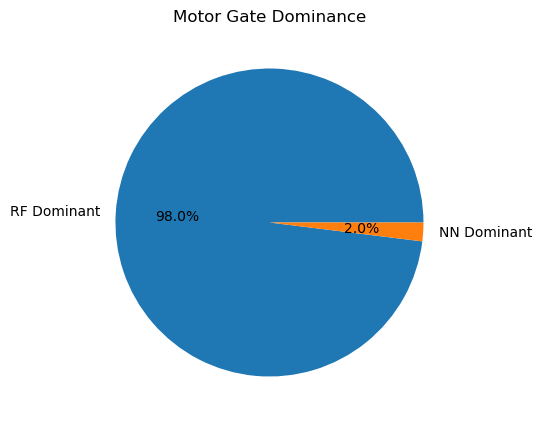

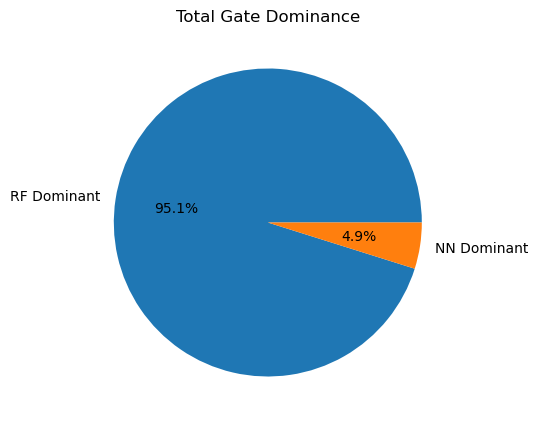

In [33]:
motor_rf_dominant = np.sum(
    motor_weights[:,0] > motor_weights[:,1]
)

motor_nn_dominant = np.sum(
    motor_weights[:,1] >= motor_weights[:,0]
)

plt.figure(figsize=(5,5))

plt.pie(
    [motor_rf_dominant, motor_nn_dominant],
    labels=["RF Dominant", "NN Dominant"],
    autopct="%1.1f%%"
)

plt.title("Motor Gate Dominance")

plt.show()

total_rf_dominant = np.sum(
    total_weights[:,0] > total_weights[:,1]
)

total_nn_dominant = np.sum(
    total_weights[:,1] >= total_weights[:,0]
)

plt.figure(figsize=(5,5))

plt.pie(
    [total_rf_dominant, total_nn_dominant],
    labels=["RF Dominant", "NN Dominant"],
    autopct="%1.1f%%"
)

plt.title("Total Gate Dominance")

plt.show()

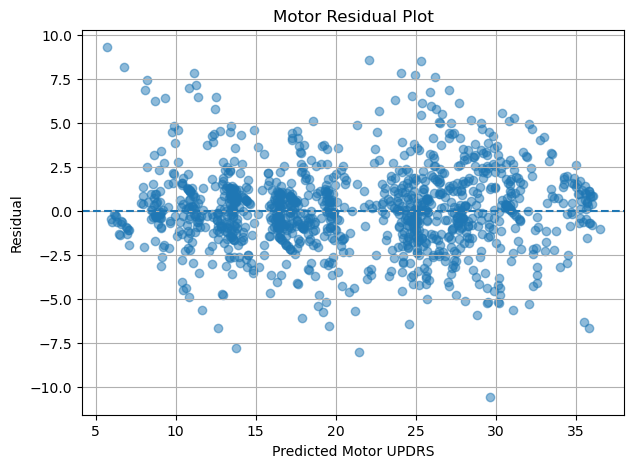

In [35]:
motor_residuals = (
    y_test[:,0]
    -
    test_preds_rescaled[:,0]
)

plt.figure(figsize=(7,5))

plt.scatter(
    test_preds_rescaled[:,0],
    motor_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Motor UPDRS")
plt.ylabel("Residual")
plt.title("Motor Residual Plot")

plt.grid(True)

plt.show()

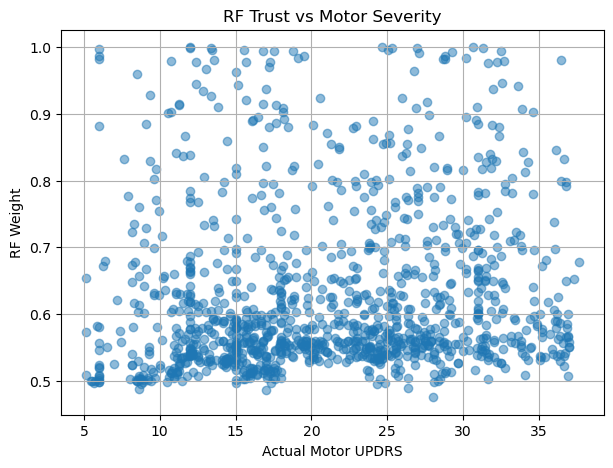

In [37]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test[:,0],
    motor_weights[:,0],
    alpha=0.5
)

plt.xlabel("Actual Motor UPDRS")
plt.ylabel("RF Weight")
plt.title("RF Trust vs Motor Severity")

plt.grid(True)

plt.show()

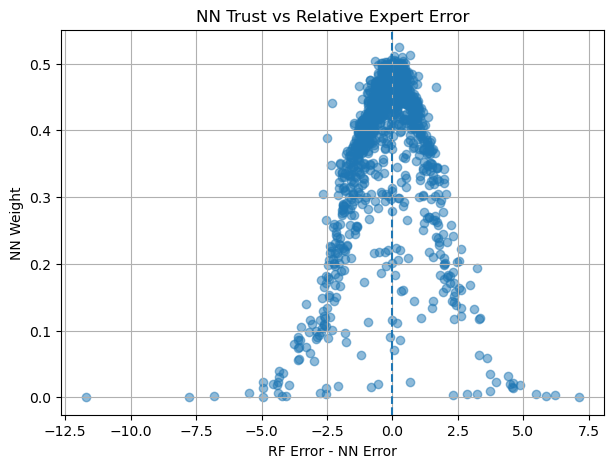

In [38]:
rf_test_rescaled = y_scaler.inverse_transform(
    rf_test_preds_scaled)
nn_test_rescaled = y_scaler.inverse_transform(
    nn_test_preds_scaled)

rf_error = np.abs(
    y_test[:,0]
    - rf_test_rescaled[:,0]
)

nn_error = np.abs(
    y_test[:,0]
    - nn_test_rescaled[:,0]
)

error_diff = rf_error - nn_error

plt.figure(figsize=(7,5))

plt.scatter(
    error_diff,
    motor_weights[:,1],
    alpha=0.5
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.xlabel("RF Error - NN Error")
plt.ylabel("NN Weight")
plt.title("NN Trust vs Relative Expert Error")

plt.grid(True)

plt.show()

In [39]:
torch.save(
    motor_gate.state_dict(),
    "../models/motor_gate.pt"
)

torch.save(
    total_gate.state_dict(),
    "../models/total_gate.pt"
)

joblib.dump(
    motor_weights,
    "../models/motor_weights.pkl"
)

joblib.dump(
    total_weights,
    "../models/total_weights.pkl"
)

print("\nDual-Gated Adaptive System exported.")


Dual-Gated Adaptive System exported.


In [58]:
with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)

Total features: 22
SHAP explainers initialized.
SHAP values generated.
SHAP values computed.
SHAP tensors processed.


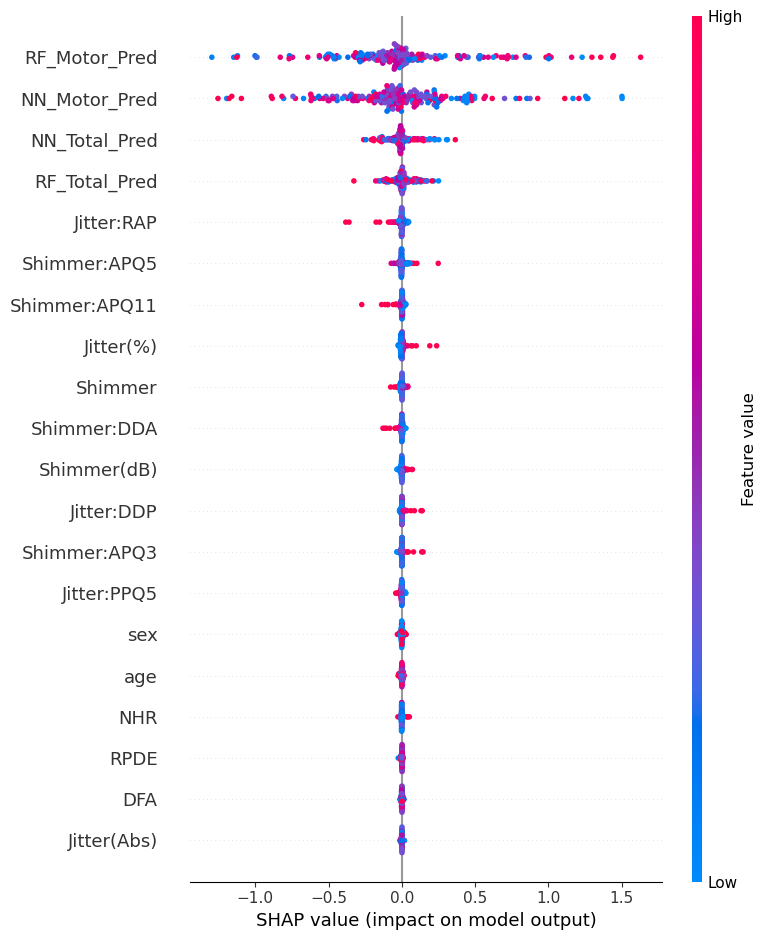

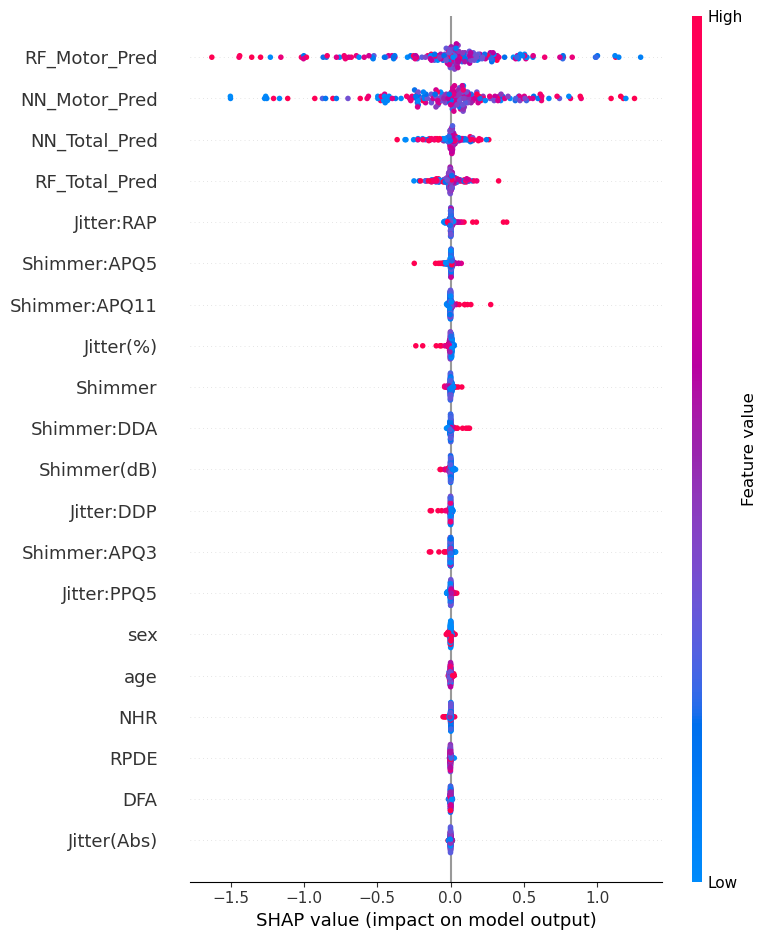

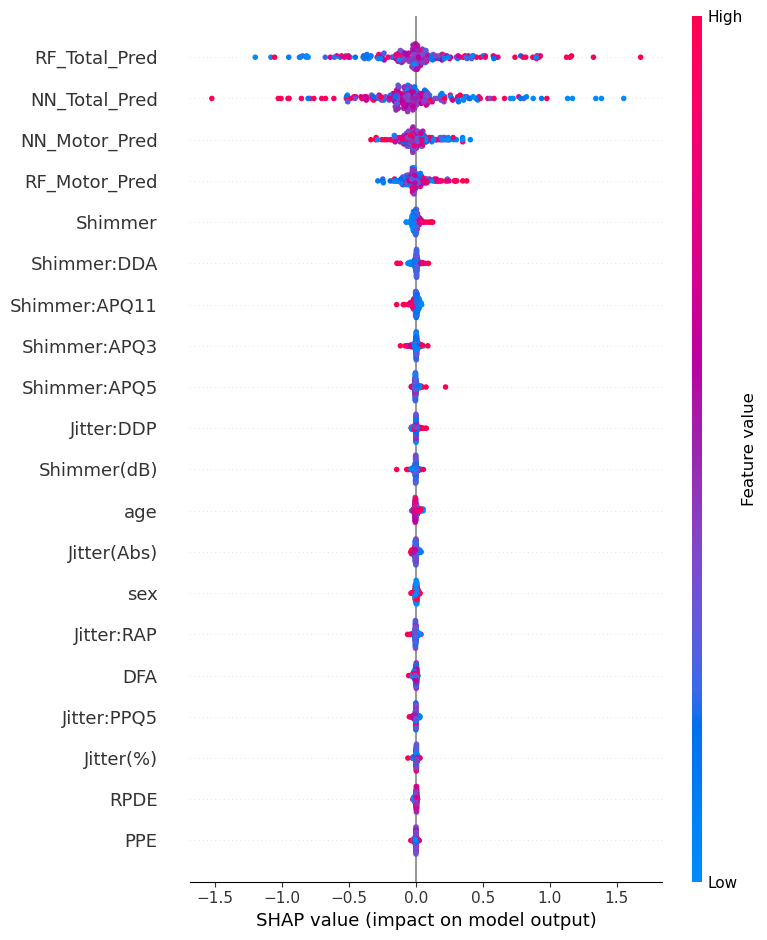

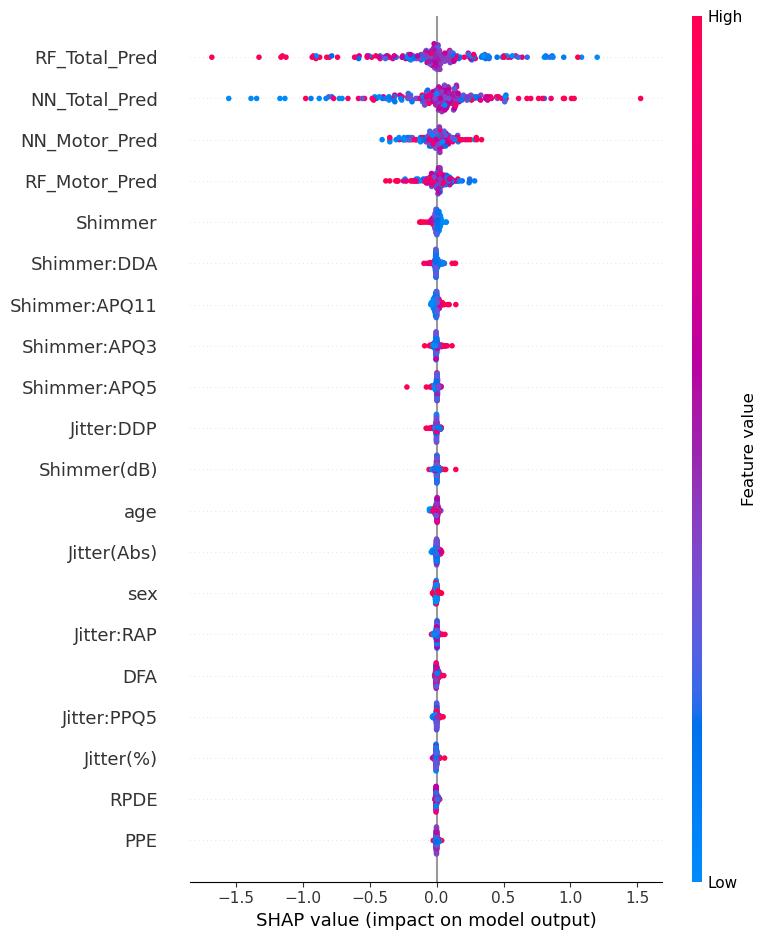

TypeError: DeepExplainer.__call__() got an unexpected keyword argument 'check_additivity'

In [59]:
# ============================================================
# SHAP ANALYSIS — DUAL GATED ROUTING EXPLAINABILITY
# ============================================================
#
# This section explains:
#
# 1. WHY the gate trusted RF/NN
# 2. Which features influenced routing
# 3. Per-sample expert allocation behavior
#
# ============================================================

import shap
import matplotlib.pyplot as plt

# ============================================================
# SECTION 1 — FEATURE NAMES
# ============================================================

# ------------------------------------------------------------
# Add Expert Prediction Features
# ------------------------------------------------------------

feature_names = feature_names + [

    "RF_Motor_Pred",
    "RF_Total_Pred",

    "NN_Motor_Pred",
    "NN_Total_Pred"
]

print(f"Total features: {len(feature_names)}")

# ============================================================
# SECTION 2 — BACKGROUND DATA
# ============================================================

# ------------------------------------------------------------
# SHAP background samples
# ------------------------------------------------------------

background = torch.tensor(
    gate_train[:100],
    dtype=torch.float32
).to(DEVICE)

# ============================================================
# SECTION 3 — CREATE EXPLAINER
# ============================================================

# ------------------------------------------------------------
# Motor Gate Explainer
# ------------------------------------------------------------

motor_explainer = shap.DeepExplainer(
    motor_gate,
    background
)

# ------------------------------------------------------------
# Total Gate Explainer
# ------------------------------------------------------------

total_explainer = shap.DeepExplainer(
    total_gate,
    background
)

print("SHAP explainers initialized.")

# ============================================================
# SECTION 4 — GLOBAL ROUTING EXPLANATION
# ============================================================

# ------------------------------------------------------------
# Explain multiple samples
# ------------------------------------------------------------

NUM_SAMPLES = 200

test_samples = torch.tensor(
    gate_test[:NUM_SAMPLES],
    dtype=torch.float32
).to(DEVICE)

# ------------------------------------------------------------
# Motor Gate SHAP
# ------------------------------------------------------------

motor_shap_values = motor_explainer.shap_values(
    test_samples,
    check_additivity=False
)

# ------------------------------------------------------------
# Total Gate SHAP
# ------------------------------------------------------------

total_shap_values = total_explainer.shap_values(
    test_samples,
    check_additivity=False
)

print("SHAP values generated.")
# ============================================================
# GLOBAL SHAP EXPLANATION
# ============================================================

NUM_SAMPLES = 200

test_samples = torch.tensor(
    gate_test[:NUM_SAMPLES],
    dtype=torch.float32
).to(DEVICE)

# ------------------------------------------------------------
# Motor Gate SHAP
# ------------------------------------------------------------

motor_shap_values = motor_explainer.shap_values(
    test_samples,
    check_additivity=False
)

# ------------------------------------------------------------
# Total Gate SHAP
# ------------------------------------------------------------

total_shap_values = total_explainer.shap_values(
    test_samples,
    check_additivity=False
)

print("SHAP values computed.")

# ============================================================
# SHAPE HANDLING
# ============================================================

# SHAP version compatibility handling

if isinstance(motor_shap_values, list):

    motor_rf_shap = motor_shap_values[0]
    motor_nn_shap = motor_shap_values[1]

else:

    motor_rf_shap = motor_shap_values[:, :, 0]
    motor_nn_shap = motor_shap_values[:, :, 1]

if isinstance(total_shap_values, list):

    total_rf_shap = total_shap_values[0]
    total_nn_shap = total_shap_values[1]

else:

    total_rf_shap = total_shap_values[:, :, 0]
    total_nn_shap = total_shap_values[:, :, 1]

print("SHAP tensors processed.")

# ============================================================
# MOTOR GATE — RF TRUST
# ============================================================

shap.summary_plot(
    motor_rf_shap,
    gate_test[:NUM_SAMPLES],
    feature_names=feature_names
)

# ============================================================
# MOTOR GATE — NN TRUST
# ============================================================

shap.summary_plot(
    motor_nn_shap,
    gate_test[:NUM_SAMPLES],
    feature_names=feature_names
)

# ============================================================
# TOTAL GATE — RF TRUST
# ============================================================

shap.summary_plot(
    total_rf_shap,
    gate_test[:NUM_SAMPLES],
    feature_names=feature_names
)

# ============================================================
# TOTAL GATE — NN TRUST
# ============================================================

shap.summary_plot(
    total_nn_shap,
    gate_test[:NUM_SAMPLES],
    feature_names=feature_names
)
# ============================================================
# SINGLE SAMPLE EXPLANATION
# ============================================================

sample_idx = 25

single_sample = torch.tensor(
    gate_test[sample_idx:sample_idx+1],
    dtype=torch.float32
).to(DEVICE)

# ------------------------------------------------------------
# SHAP Values
# ------------------------------------------------------------

single_motor_shap = motor_explainer(
    single_sample,
    check_additivity=False
)

single_total_shap = total_explainer(
    single_sample,
    check_additivity=False
)

# ============================================================
# MOTOR RF TRUST EXPLANATION
# ============================================================

print("\n===== MOTOR GATE =====")
print(f"RF Weight : {motor_weights[sample_idx,0]:.4f}")
print(f"NN Weight : {motor_weights[sample_idx,1]:.4f}")

shap.plots.waterfall(
    single_motor_shap[0, :, 0],
    max_display=15
)

# ============================================================
# TOTAL RF TRUST EXPLANATION
# ============================================================

print("\n===== TOTAL GATE =====")
print(f"RF Weight : {total_weights[sample_idx,0]:.4f}")
print(f"NN Weight : {total_weights[sample_idx,1]:.4f}")

shap.plots.waterfall(
    single_total_shap[0, :, 0],
    max_display=15
)



In [21]:
# ============================================================
# RF FEATURE IMPORTANCE + GATE WEIGHTS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# FEATURE NAMES
# ============================================================

feature_names = feature_names + [

    "RF_Motor_Pred",
    "RF_Total_Pred",

    "NN_Motor_Pred",
    "NN_Total_Pred"
]

print(f"Total features: {len(feature_names)}")

# ============================================================
# SHARED RF FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({

    "Feature": feature_names[:18],
    "Importance": rf_expert.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("SHARED RF FEATURE IMPORTANCE")
print("==============================")

print(rf_importance)

# ============================================================
# PRINT GATE WEIGHTS
# ============================================================

NUM_SAMPLES = 20

print("\n==============================")
print("MOTOR GATE WEIGHTS")
print("==============================")

for i in range(NUM_SAMPLES):

    print(
        f"Sample {i} | "
        f"RF Weight = {motor_weights[i,0]:.4f} | "
        f"NN Weight = {motor_weights[i,1]:.4f}"
    )

print("\n==============================")
print("TOTAL GATE WEIGHTS")
print("==============================")

for i in range(NUM_SAMPLES):

    print(
        f"Sample {i} | "
        f"RF Weight = {total_weights[i,0]:.4f} | "
        f"NN Weight = {total_weights[i,1]:.4f}"
    )

# ============================================================
# OPTIONAL:
# SHOW INPUT FEATURES FOR HIGH RF TRUST
# ============================================================

print("\n==============================")
print("HIGH RF TRUST SAMPLES")
print("==============================")

# samples where RF trusted more than NN

high_rf_idx = np.where(motor_weights[:,0] > 0.8)[0]

for idx in high_rf_idx[:10]:

    print(f"\nSample {idx}")

    print(f"RF Weight : {motor_weights[idx,0]:.4f}")
    print(f"NN Weight : {motor_weights[idx,1]:.4f}")

    print("\nTop Input Features:")

    sample_features = gate_test[idx][:18]

    sorted_idx = np.argsort(np.abs(sample_features))[::-1]

    for j in sorted_idx[:5]:

        print(
            f"{feature_names[j]} = "
            f"{sample_features[j]:.4f}"
        )

Total features: 26

SHARED RF FEATURE IMPORTANCE
          Feature  Importance
0             age    0.672059
16            DFA    0.096306
1             sex    0.081533
3     Jitter(Abs)    0.025036
15           RPDE    0.017892
14            HNR    0.016208
17            PPE    0.013497
13            NHR    0.010003
11  Shimmer:APQ11    0.009722
10   Shimmer:APQ5    0.008493
8     Shimmer(dB)    0.008002
7         Shimmer    0.006995
12    Shimmer:DDA    0.006663
9    Shimmer:APQ3    0.006498
2       Jitter(%)    0.005722
5     Jitter:PPQ5    0.005643
6      Jitter:DDP    0.005223
4      Jitter:RAP    0.004506

MOTOR GATE WEIGHTS
Sample 0 | RF Weight = 0.6870 | NN Weight = 0.3130
Sample 1 | RF Weight = 0.5747 | NN Weight = 0.4253
Sample 2 | RF Weight = 0.5288 | NN Weight = 0.4712
Sample 3 | RF Weight = 0.6289 | NN Weight = 0.3711
Sample 4 | RF Weight = 0.5434 | NN Weight = 0.4566
Sample 5 | RF Weight = 0.5369 | NN Weight = 0.4631
Sample 6 | RF Weight = 0.5512 | NN Weight = 0.4488
Samp

In [29]:
# ============================================================
# SHAP EXPLAINABILITY — SHARED MULTI-OUTPUT NN
# ============================================================

import shap
import torch
import numpy as np

# ============================================================
# FEATURE NAMES
# ============================================================

# ONLY original NN input features
feature_names = feature_names[:18]

# ============================================================
# BACKGROUND DATA
# ============================================================

background = torch.tensor(
    X_train[:100],
    dtype=torch.float32
).to(DEVICE)

# ============================================================
# TEST SAMPLES
# ============================================================

NUM_SAMPLES = 200

test_samples = torch.tensor(
    X_test[:NUM_SAMPLES],
    dtype=torch.float32
).to(DEVICE)

# ============================================================
# CREATE EXPLAINER
# ============================================================

explainer = shap.GradientExplainer(
    nn_model,
    background
)

print("GradientExplainer initialized.")

# ============================================================
# COMPUTE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(test_samples)

print("SHAP values computed.")

# ============================================================
# HANDLE MULTI-OUTPUT SHAP FORMAT
# ============================================================

if isinstance(shap_values, list):

    # Standard multi-output format
    motor_shap = shap_values[0]
    total_shap = shap_values[1]

else:

    # Fallback tensor format
    motor_shap = shap_values[:, :, 0]
    total_shap = shap_values[:, :, 1]

print("SHAP tensors processed.")

# ============================================================
# GLOBAL SHAP SUMMARY — MOTOR UPDRS
# ============================================================

print("\n==============================")
print("GLOBAL MOTOR UPDRS SHAP")
print("==============================")

shap.summary_plot(
    motor_shap,
    X_test[:NUM_SAMPLES],
    feature_names=feature_names,
    show=False
)
plt.savefig("../results/motor_shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

# ============================================================
# GLOBAL SHAP SUMMARY — TOTAL UPDRS
# ============================================================

print("\n==============================")
print("GLOBAL TOTAL UPDRS SHAP")
print("==============================")

shap.summary_plot(
    total_shap,
    X_test[:NUM_SAMPLES],
    feature_names=feature_names,
    show=False
)
plt.savefig("../results/total_shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

# ============================================================
# SAMPLE-WISE FEATURE IMPORTANCE
# ============================================================

sample_idx = 25

print("\n==============================")
print(f"SAMPLE {sample_idx}")
print("==============================")

# ------------------------------------------------------------
# MOTOR UPDRS SAMPLE EXPLANATION
# ------------------------------------------------------------
print("\nMOTOR UPDRS FEATURE CONTRIBUTIONS")

motor_sample_shap = motor_shap[sample_idx]

motor_sorted_idx = np.argsort(
    np.abs(motor_sample_shap)
)[::-1]

for idx in motor_sorted_idx[:10]:

    print(
        f"{feature_names[idx]} | "
        f"Feature Value = {X_test[sample_idx][idx]:.4f} | "
        f"SHAP = {motor_sample_shap[idx]:.4f}"
    )

# ------------------------------------------------------------
# TOTAL UPDRS SAMPLE EXPLANATION
# ------------------------------------------------------------

print("\nTOTAL UPDRS FEATURE CONTRIBUTIONS")

total_sample_shap = total_shap[sample_idx]

total_sorted_idx = np.argsort(
    np.abs(total_sample_shap)
)[::-1]

for idx in total_sorted_idx[:10]:

    print(
        f"{feature_names[idx]} | "
        f"Feature Value = {X_test[sample_idx][idx]:.4f} | "
        f"SHAP = {total_sample_shap[idx]:.4f}"
    )

# ============================================================
# COMPUTE BASE VALUES MANUALLY
# ============================================================

with torch.no_grad():

    background_preds = nn_model(background).cpu().numpy()

# Multi-output:
# column 0 -> Motor
# column 1 -> Total

motor_base_value = background_preds[:, 0].mean()
total_base_value = background_preds[:, 1].mean()

print("\nBase values computed.")

# ============================================================
# MOTOR WATERFALL
# ============================================================

print("\n==============================")
print("MOTOR WATERFALL")
print("==============================")

shap.plots.waterfall(

    shap.Explanation(

        values=motor_sample_shap,

        base_values=motor_base_value,

        data=X_test[sample_idx],

        feature_names=feature_names
    ),

    max_display=15,
    show=False
)

plt.savefig("../results/motor_waterfall.png", dpi=300, bbox_inches="tight")
plt.close()
# ============================================================
# TOTAL WATERFALL
# ============================================================

print("\n==============================")
print("TOTAL WATERFALL")
print("==============================")

shap.plots.waterfall(

    shap.Explanation(

        values=total_sample_shap,

        base_values=total_base_value,

        data=X_test[sample_idx],

        feature_names=feature_names
    ),

    max_display=15,
    show=False
)

plt.savefig("../results/total_waterfall.png", dpi=300, bbox_inches="tight")
plt.close()

GradientExplainer initialized.
SHAP values computed.
SHAP tensors processed.

GLOBAL MOTOR UPDRS SHAP

GLOBAL TOTAL UPDRS SHAP

SAMPLE 25

MOTOR UPDRS FEATURE CONTRIBUTIONS
age | Feature Value = -0.3170 | SHAP = 0.5999
HNR | Feature Value = -3.9476 | SHAP = 0.3815
NHR | Feature Value = 5.7408 | SHAP = 0.3273
Shimmer(dB) | Feature Value = 6.0621 | SHAP = -0.2754
sex | Feature Value = 1.4971 | SHAP = -0.2299
Shimmer:APQ3 | Feature Value = 4.8814 | SHAP = 0.1345
Shimmer | Feature Value = 6.0119 | SHAP = -0.1126
Shimmer:DDA | Feature Value = 4.8816 | SHAP = 0.1087
DFA | Feature Value = -0.6410 | SHAP = 0.1002
Jitter:DDP | Feature Value = 4.2343 | SHAP = 0.0738

TOTAL UPDRS FEATURE CONTRIBUTIONS
age | Feature Value = -0.3170 | SHAP = 0.4082
Shimmer | Feature Value = 6.0119 | SHAP = -0.2337
HNR | Feature Value = -3.9476 | SHAP = 0.2326
Shimmer:APQ3 | Feature Value = 4.8814 | SHAP = 0.2145
NHR | Feature Value = 5.7408 | SHAP = 0.2116
Shimmer(dB) | Feature Value = 6.0621 | SHAP = -0.2084
sex |

In [ ]:
# ============================================================
# CLINICIAN-STYLE EXPLAINABLE PREDICTION
# ============================================================

import numpy as np
import torch
import shap

# ============================================================
# FEATURE DESCRIPTIONS
# ============================================================

feature_descriptions = {

    "age":
        "patient age",

    "sex":
        "biological sex",

    "Jitter(%)":
        "vocal frequency instability (Jitter %)",

    "Jitter(Abs)":
        "absolute vocal instability (Jitter Abs)",

    "Jitter:RAP":
        "rapid vocal fluctuation irregularities (Jitter RAPID)",

    "Jitter:PPQ5":
        "short-term vocal frequency variation (Jitter PPQ5)",

    "Jitter:DDP":
        "cycle-to-cycle vocal disturbance (Jitter DDP)",

    "Shimmer":
        "vocal amplitude instability",

    "Shimmer(dB)":
        "loudness instability",

    "Shimmer:APQ3":
        "short-term amplitude perturbation",

    "Shimmer:APQ5":
        "medium-term amplitude perturbation",

    "Shimmer:APQ11":
        "long-term amplitude perturbation",

    "Shimmer:DDA":
        "amplitude disturbance variability",

    "NHR":
        "noise-to-harmonic vocal irregularity",

    "HNR":
        "harmonic voice stability",

    "RPDE":
        "speech pattern complexity irregularity",

    "DFA":
        "speech signal fluctuation behavior",

    "PPE":
        "phonation pattern irregularity"
}

# ============================================================
# HUMAN-FRIENDLY FEATURE PHRASING
# ============================================================

def format_feature_explanation(

    feature_name,
    shap_value,
    raw_value
):

    # ========================================================
    # AGE
    # ========================================================

    if feature_name == "age":

        age = int(raw_value)

        # Only mention age if clinically notable

        if age >= 60:

            return f"the patient's age ({age} years)"

        else:

            return None

    # ========================================================
    # SEX
    # ========================================================

    if feature_name == "sex":

        gender = "female" if raw_value == 1 else "male"

        return f"the patient's gender ({gender})"

    # ========================================================
    # DEFAULT FEATURES
    # ========================================================

    if shap_value > 0:

        impact = "elevated"

    else:

        impact = "reduced"

    description = feature_descriptions[feature_name]

    return f"{impact} {description}"

# ============================================================
# MAIN EXPLAINABILITY FUNCTION
# ============================================================

def explain_prediction(raw_input):

    """
    raw_input:
        list / numpy array of 18 raw feature values
    """

    print("\n================================================")
    print("PARKINSON'S PREDICTION EXPLANATION")
    print("================================================")

    # ========================================================
    # PREP INPUT
    # ========================================================

    raw_input = np.array(raw_input).reshape(1, -1)

    # Scale input
    X_scaled = scaler.transform(raw_input)

    # ========================================================
    # RF PREDICTION
    # ========================================================

    rf_preds = rf_expert.predict(X_scaled)

    rf_motor = rf_preds[0][0]
    rf_total = rf_preds[0][1]

    # ========================================================
    # NN PREDICTION
    # ========================================================

    nn_input = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(DEVICE)

    nn_model.eval()

    with torch.no_grad():

        nn_preds = nn_model(nn_input).cpu().numpy()

    nn_motor = nn_preds[0][0]
    nn_total = nn_preds[0][1]

    # ========================================================
    # BUILD GATE INPUT
    # ========================================================

    gate_input = np.concatenate([

        X_scaled[0],

        [
            rf_motor,
            rf_total,
            nn_motor,
            nn_total
        ]

    ]).reshape(1, -1)

    gate_tensor = torch.tensor(
        gate_input,
        dtype=torch.float32
    ).to(DEVICE)

    # ========================================================
    # MOTOR GATE
    # ========================================================

    motor_gate.eval()

    with torch.no_grad():

        motor_weights = (
            motor_gate(gate_tensor)
            .cpu()
            .numpy()[0]
        )

    motor_rf_weight = float(motor_weights[0])
    motor_nn_weight = float(motor_weights[1])

    # ========================================================
    # TOTAL GATE
    # ========================================================

    total_gate.eval()

    with torch.no_grad():

        total_weights = (
            total_gate(gate_tensor)
            .cpu()
            .numpy()[0]
        )

    total_rf_weight = float(total_weights[0])
    total_nn_weight = float(total_weights[1])

    # ========================================================
    # FINAL ADAPTIVE PREDICTIONS
    # ========================================================

    final_motor = (

        motor_rf_weight * rf_motor +

        motor_nn_weight * nn_motor
    )

    final_total = (

        total_rf_weight * rf_total +

        total_nn_weight * nn_total
    )

    # ========================================================
    # SHAP ANALYSIS FOR NN
    # ========================================================

    sample_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(DEVICE)

    shap_values = explainer.shap_values(
        sample_tensor
    )

    # ========================================================
    # MULTI-OUTPUT HANDLING
    # ========================================================

    if isinstance(shap_values, list):

        motor_shap = shap_values[0][0]
        total_shap = shap_values[1][0]

    else:

        motor_shap = shap_values[0, :, 0]
        total_shap = shap_values[0, :, 1]

    # ========================================================
    # TOP FEATURES
    # ========================================================

    motor_top_idx = np.argsort(
        np.abs(motor_shap)
    )[::-1][:3]

    total_top_idx = np.argsort(
        np.abs(total_shap)
    )[::-1][:3]

    # ========================================================
    # MOTOR EXPLANATION
    # ========================================================

    print("\n================================================")
    print("MOTOR UPDRS")
    print("================================================")

    print(
        f"\nPredicted Score : "
        f"{y_scaler.inverse_transform([[final_motor, 0]])[0][0]:.2f}"
    )

    print("\nExpert Confidence Allocation:")

    print(
        f"- Random Forest Expert : "
        f"{motor_rf_weight * 100:.1f}%"
    )

    print(
        f"- Neural Network Expert : "
        f"{motor_nn_weight * 100:.1f}%"
    )

    print("\nWhy was this prediction made?\n")

    # ========================================================
    # DYNAMIC MOTOR EXPLANATION
    # ========================================================

    motor_reasoning = []

    for idx in motor_top_idx:

        feature_name = feature_names[idx]

        shap_value = motor_shap[idx]

        raw_value = raw_input[0][idx]

        formatted = format_feature_explanation(

            feature_name,
            shap_value,
            raw_value
        )

        if formatted is not None:

            motor_reasoning.append(formatted)

    # ========================================================
    # BUILD MOTOR SENTENCE
    # ========================================================

    if len(motor_reasoning) > 1:

        motor_sentence = ", ".join(
            motor_reasoning[:-1]
        ) + f", and {motor_reasoning[-1]}"

    else:

        motor_sentence = motor_reasoning[0]

    # ========================================================
    # PRINT MOTOR EXPLANATION
    # ========================================================

    print(

        f"The prediction was primarily influenced by "
        f"{motor_sentence}. "

        f"These characteristics are commonly associated "
        f"with Parkinsonian motor progression and "
        f"speech-related abnormalities."
    )

    # ========================================================
    # MOTOR ROUTING EXPLANATION
    # ========================================================

    if motor_rf_weight > 0.7:

        print(
            "\nThe system relied primarily on the "
            "Random Forest expert because the "
            "patient's feature pattern closely "
            "matched structured progression patterns "
            "seen during training."
        )

    elif motor_nn_weight > 0.7:

        print(
            "\nThe system relied more heavily on the "
            "Neural Network expert because the "
            "feature interactions appeared more "
            "complex and nonlinear."
        )

    else:

        print(
            "\nBoth experts contributed significantly, "
            "suggesting a balanced combination of "
            "structured and nonlinear disease patterns."
        )

    # ========================================================
    # TOTAL EXPLANATION
    # ========================================================

    print("\n================================================")
    print("TOTAL UPDRS")
    print("================================================")

    print(
        f"\nPredicted Score : "
        f"{y_scaler.inverse_transform([[0, final_total]])[0][1]:.2f}"
    )

    print("\nExpert Confidence Allocation:")

    print(
        f"- Random Forest Expert : "
        f"{total_rf_weight * 100:.1f}%"
    )

    print(
        f"- Neural Network Expert : "
        f"{total_nn_weight * 100:.1f}%"
    )

    print("\nWhy was this prediction made?\n")

    # ========================================================
    # DYNAMIC TOTAL EXPLANATION
    # ========================================================

    total_reasoning = []

    for idx in total_top_idx:

        feature_name = feature_names[idx]

        shap_value = total_shap[idx]

        raw_value = raw_input[0][idx]

        formatted = format_feature_explanation(

            feature_name,
            shap_value,
            raw_value
        )

        if formatted is not None:

            total_reasoning.append(formatted)

    # ========================================================
    # BUILD TOTAL SENTENCE
    # ========================================================

    if len(total_reasoning) > 1:

        total_sentence = ", ".join(
            total_reasoning[:-1]
        ) + f", and {total_reasoning[-1]}"

    else:

        total_sentence = total_reasoning[0]

    # ========================================================
    # PRINT TOTAL EXPLANATION
    # ========================================================

    print(

        f"The prediction was mainly driven by "
        f"{total_sentence}. "

        f"These patterns are associated with "
        f"overall Parkinson's disease severity "
        f"and progression behavior."
    )

    # ========================================================
    # TOTAL ROUTING EXPLANATION
    # ========================================================

    if total_rf_weight > 0.7:

        print(
            "\nThe system relied primarily on the "
            "Random Forest expert because the "
            "overall feature profile resembled "
            "known structured progression cases."
        )

    elif total_nn_weight > 0.7:

        print(
            "\nThe system relied more heavily on the "
            "Neural Network expert because the "
            "overall feature interactions appeared "
            "more nonlinear and complex."
        )

    else:

        print(
            "\nBoth experts contributed meaningfully "
            "to the final prediction, indicating "
            "mixed progression characteristics."
        )

    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "motor_prediction": final_motor,

        "total_prediction": final_total,

        "motor_rf_confidence": motor_rf_weight,

        "motor_nn_confidence": motor_nn_weight,

        "total_rf_confidence": total_rf_weight,

        "total_nn_confidence": total_nn_weight
    }

In [39]:
# ============================================================
# RANDOM TEST SAMPLE PIPELINE
# ============================================================

import random
# ============================================================
# LOAD RAW DATASET
# ============================================================

# Replace with your actual dataset path
DATA_PATH = '../data/raw/parkinsons_updrs.data.csv'

df = pd.read_csv(DATA_PATH)

# ============================================================
# SELECT INPUT FEATURES
# ============================================================

input_features = [

    "age",
    "sex",

    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",

    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",

    "NHR",
    "HNR",

    "RPDE",
    "DFA",
    "PPE"
]

# ============================================================
# PICK RANDOM SAMPLE
# ============================================================

random_idx = random.randint(0, len(df) - 1)

sample_row = df.iloc[random_idx]

# ============================================================
# EXTRACT RAW FEATURES
# ============================================================

raw_sample = sample_row[input_features].values.astype(float)

# ============================================================
# SHOW INPUT FEATURES
# ============================================================

print("\n================================================")
print("RAW INPUT FEATURES")
print("================================================")

for feature, value in zip(input_features, raw_sample):

    print(f"{feature:20s} : {value}")

# ============================================================
# RUN FULL EXPLAINABILITY PIPELINE
# ============================================================

results = explain_prediction(raw_sample)

# ============================================================
# FINAL OUTPUT SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print(
    f"\nPredicted Motor UPDRS : "
    f"{y_scaler.inverse_transform([[results['motor_prediction'], 0]])[0][0]:.2f}"
)

print(
    f"Predicted Total UPDRS : "
    f"{y_scaler.inverse_transform([[0, results['total_prediction']]])[0][1]:.2f}"
)

print("\nMotor Expert Allocation:")

print(
    f"- RF : "
    f"{results['motor_rf_confidence'] * 100:.1f}%"
)

print(
    f"- NN : "
    f"{results['motor_nn_confidence'] * 100:.1f}%"
)

print("\nTotal Expert Allocation:")

print(
    f"- RF : "
    f"{results['total_rf_confidence'] * 100:.1f}%"
)

print(
    f"- NN : "
    f"{results['total_nn_confidence'] * 100:.1f}%"
)


RAW INPUT FEATURES
age                  : 66.0
sex                  : 1.0
Jitter(%)            : 0.00336
Jitter(Abs)          : 1.204e-05
Jitter:RAP           : 0.00158
Jitter:PPQ5          : 0.00175
Jitter:DDP           : 0.00474
Shimmer              : 0.03451
Shimmer(dB)          : 0.31
Shimmer:APQ3         : 0.01859
Shimmer:APQ5         : 0.0206
Shimmer:APQ11        : 0.02727
Shimmer:DDA          : 0.05577
NHR                  : 0.011702
HNR                  : 20.968
RPDE                 : 0.47827
DFA                  : 0.56562
PPE                  : 0.22386

PARKINSON'S PREDICTION EXPLANATION

MOTOR UPDRS

Predicted Score : 25.00

Expert Confidence Allocation:
- Random Forest Expert : 55.1%
- Neural Network Expert : 44.9%

Why was this prediction made?

The prediction was primarily influenced by the patient's gender (female), the patient's age (66 years), and reduced absolute vocal instability. These characteristics are commonly associated with Parkinsonian motor progression and s